# Лабораторна робота: Аналіз даних Titanic: Класифікація виживання пасажирів

Мета роботи побудувати та порівняти моделі машинного навчання (Логістична регресія, Дерево рішень, Випадковий ліс) для передбачення виживання пасажирів Титаніка.

П.с. Для написання коментарів було використано ШІ


**Етапи:**
1. Підготовка даних та EDA (Розвідувальний аналіз).
2. Feature Engineering (Створення нових ознак).
3. Побудова та оцінка базових моделей.
4. Оптимізація гіперпараметрів.
5. Аналіз важливості ознак.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

sns.set(style="whitegrid")
print("Бібліотеки успішно імпортовано!")

Бібліотеки успішно імпортовано!


Перші 10 рядків


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False



 Інформація про дані та пропуски
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

 Базова статистика


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


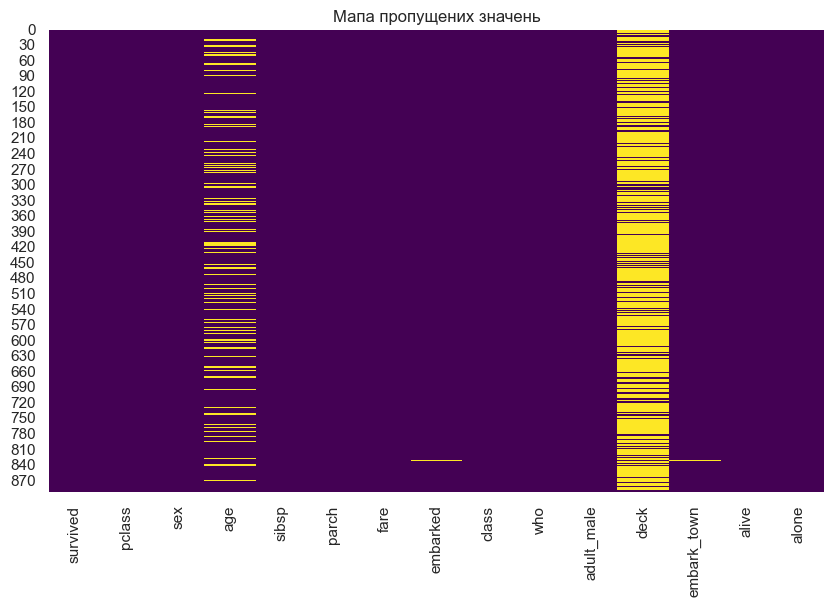

In [ ]:
df = sns.load_dataset('titanic')

print("Перші 10 рядків")
display(df.head(10))

print("\n Інформація про дані та пропуски")
print(df.info())

print("\n Базова статистика")
display(df.describe())

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Мапа пропущених значень")
plt.show()

In [ ]:
df['age'] = df['age'].fillna(df['age'].mean())


most_common_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(most_common_embarked)

cols_to_drop = ['deck', 'embark_town', 'alive', 'who', 'class', 'adult_male']
df = df.drop(columns=cols_to_drop)

df['FamilySize'] = df['sibsp'] + df['parch']

df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

print("Дані після обробки:")
display(df.head())

Дані після обробки:


,survived,pclass,age,sibsp,parch,fare,alone,FamilySize,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,1,True,False,True
1,1,1,38.0,1,0,71.2833,False,1,False,False,False
2,1,3,26.0,0,0,7.9250,True,0,False,False,True
3,1,1,35.0,1,0,53.1000,False,1,False,False,True
4,0,3,35.0,0,0,8.0500,True,0,True,False,True


In [ ]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір тренувальної вибірки: (712, 10)
Розмір тестової вибірки: (179, 10)



--- Logistic Regression Confusion Matrix ---
[[90 15]
 [20 54]]

--- Decision Tree Confusion Matrix ---
[[88 17]
 [20 54]]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37756\1710449774.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_table = pd.concat([results_table, new_row], ignore_index=True)



--- Random Forest Confusion Matrix ---
[[91 14]
 [18 56]]


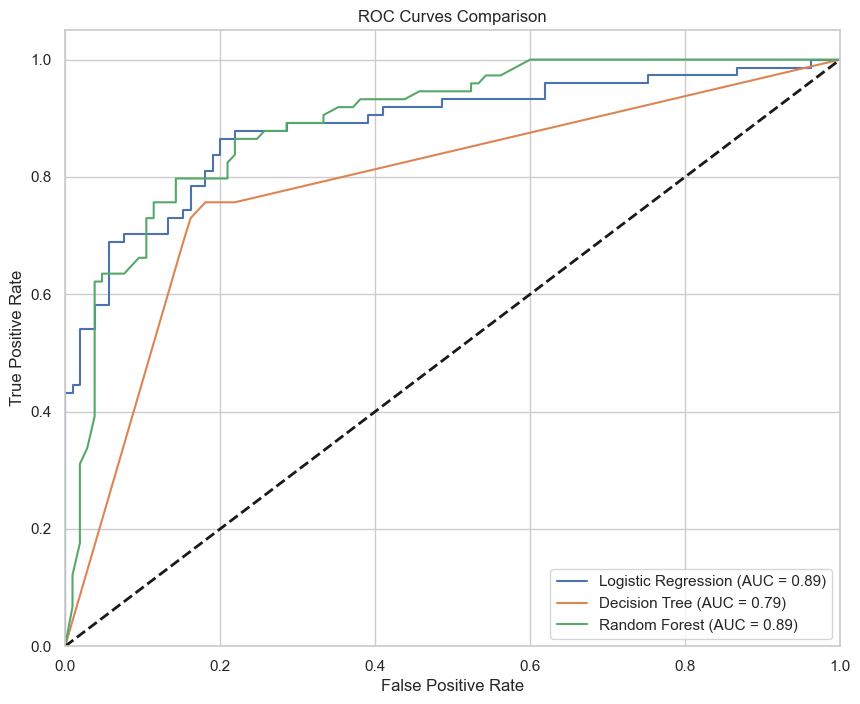


--- Порівняльна таблиця метрик ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.804469,0.782609,0.729730,0.755245
1,Decision Tree,0.793296,0.760563,0.729730,0.744828
2,Random Forest,0.821229,0.800000,0.756757,0.777778


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results_table = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] 
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    new_row = pd.DataFrame({
        "Model": [name], "Accuracy": [acc], "Precision": [prec], 
        "Recall": [rec], "F1-Score": [f1]
    })
    results_table = pd.concat([results_table, new_row], ignore_index=True)
    
    print(f"\n--- {name} Confusion Matrix ---")
    print(confusion_matrix(y_test, y_pred))
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.show()

print("\n--- Порівняльна таблиця метрик ---")
display(results_table)

In [ ]:
print("--- Крос-валідація (Cross-Validation) ---")
for name, model in models.items():
    if name != "Random Forest": 
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
        print(f"{name} CV Average Accuracy: {cv_scores.mean():.4f}")

print("\n--- Grid Search для Random Forest ---")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Найкращі параметри: {grid_search.best_params_}")
print(f"Найкраща точність на валідації: {grid_search.best_score_:.4f}")

--- Крос-валідація (Cross-Validation) ---
Logistic Regression CV Average Accuracy: 0.7946
Decision Tree CV Average Accuracy: 0.7756

--- Grid Search для Random Forest ---
Найкращі параметри: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Найкраща точність на валідації: 0.8202


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37756\1587462211.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


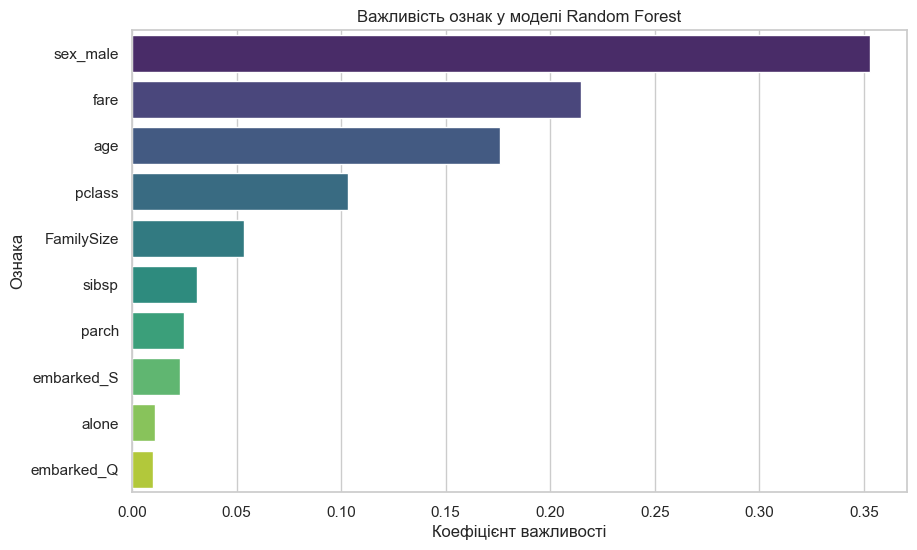


--- Висновки та Ідеї ---
1. Найвпливовіші ознаки: Зазвичай це стать (sex_male) та ціна квитка (fare) або вік.
2. Пропозиція покращення: 
   - Можна виділити титули з імен (Mr, Mrs, Miss), оскільки вони краще вказують на соціальний статус, ніж просто Pclass.
   - Створити ознаку IsAlone (якщо FamilySize == 0).
   - Використати метод KNN Imputer для більш точного заповнення віку замість середнього значення.



In [ ]:
importances = best_rf.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Важливість ознак у моделі Random Forest')
plt.xlabel('Коефіцієнт важливості')
plt.ylabel('Ознака')
plt.show()

print("""
Висновки 
1. Найвпливовіші ознаки: Зазвичай це стать (sex_male) та ціна квитка (fare) або вік.
2. Пропозиція покращення: 
   - Можна виділити титули з імен (Mr, Mrs, Miss), оскільки вони краще вказують на соціальний статус, ніж просто Pclass.
   - Створити ознаку IsAlone (якщо FamilySize == 0).
   - Використати метод KNN Imputer для більш точного заповнення віку замість середнього значення.
""")